In [1]:
from pathlib import Path
from datetime import datetime
import os
import netCDF4 as nc  
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import xarray as xr
import neuralhydrology.evaluation.metrics as nhm

In [ ]:
def metric_generator(result_path, tmp_basins_path, spc_basins_path):

    tmp_basin_list = []
    spc_basin_list = []
    metric_list_cal=[]
    metric_list_tmp=[]
    metric_list_spc=[]
    metric_list_spc_tmp=[]
    missing_basins=[]

    with open(Path(tmp_basins_path)) as f:
        for line in f:
            # remove whitespace at the start and the newline at the end
            line = line.strip()
            tmp_basin_list.append(line)
    with open(Path(spc_basins_path)) as f:
        for line in f:
            # remove whitespace at the start and the newline at the end
            line = line.strip()
            spc_basin_list.append(line)

    # Temporal
    for basin in tqdm(tmp_basin_list):
        file_to_read=Path(result_path) / f'{basin}.csv'

        if not (os.path.isfile(file_to_read)):
            missing_basins.append(basin)
            continue

        df= pd.read_csv(file_to_read, index_col=[0])
        df_cal = df[df.index < '2018-01-01']
        df_tmp = df[(df.index >= '2018-01-01') & (df.index < '2024-12-31')]

        kge_cal=nhm.kge(df_cal['qobs_mmd'] , df_cal['qsim_mmd'])
        metric_list_cal.append((basin,kge_cal))

        kge_tmp=nhm.kge(df_tmp['qobs_mmd'] , df_tmp['qsim_mmd'])
        metric_list_tmp.append((basin,kge_tmp))

    metrics_cal=pd.DataFrame(metric_list_cal, columns=["basin","KGE"])  
    metrics_tmp=pd.DataFrame(metric_list_tmp, columns=["basin","KGE"]) 

    # Spatial
    for basin in tqdm(spc_basin_list):
        file_to_read=Path(result_path) / f'{basin}.csv'

        if not (os.path.isfile(file_to_read)):
            missing_basins.append(basin)
            continue

        df= pd.read_csv(file_to_read, index_col=[0])
        df_spc = df[df.index < '2011-01-01']
        df_spc_tmp = df[(df.index >= '2011-01-01') & (df.index < '2018-01-01')]

        kge_spc=nhm.kge(df_spc['qobs_mmd'] , df_spc['qsim_mmd'])
        metric_list_spc.append((basin,kge_spc))

        kge_spc_tmp=nhm.kge(df_spc_tmp['qobs_mmd'] , df_spc_tmp['qsim_mmd'])
        metric_list_spc_tmp.append((basin,kge_spc_tmp))

    metrics_spc=pd.DataFrame(metric_list_spc, columns=["basin","KGE"])  
    metrics_spc_tmp=pd.DataFrame(metric_list_spc_tmp, columns=["basin","KGE"]) 

    # metric.to_csv(run_dir+"/"+ 'metrics_tmprics.csv')
    metrics_cal.to_csv("results/"+'metrics' +'_cal' + '.csv')
    metrics_tmp.to_csv("results/"+'metrics' +'_tmp' + '.csv')
    # metrics_spc.to_csv("runs/"+'metrics' +'_spc' + '.csv')
    # metrics_spc_tmp.to_csv("runs/"+'metrics' +'_spc_tmp' + '.csv')
    return metrics_cal, metrics_tmp, metrics_spc, metrics_spc_tmp
    # return metrics_cal, metrics_tmp

In [4]:
# Define variables
result_path='results/'
tmp_basins_path = '/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/data_newbasins_WEST/LSTM_CaSR3.2_forcings_2000_2024/basins/west_selbasins.txt'
spc_basins_path = '/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/data/LSTM_CaSR3.2_forcings_2000_2023/basins/no_basins.txt' 

metrics_cal, metrics_tmp, metrics_spc, metrics_spc_tmp = metric_generator(result_path, tmp_basins_path, spc_basins_path)
# metrics_cal, metrics_tmp = metric_generator(result_path, tmp_basins_path, spc_basins_path)

  0%|          | 0/141 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

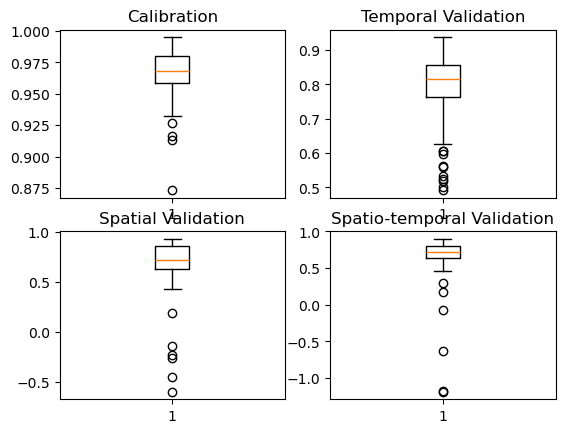

In [5]:

# fig, axs = plt.subplots(2,2)

# axs[0,0].boxplot(metrics_cal['KGE'])
# axs[0,0].set_title('Calibration')

# axs[0,1].boxplot(metrics_tmp['KGE'])
# axs[0,1].set_title('Temporal Validation')

# # axs[1, 0].boxplot(metrics_spc['KGE'])
# # axs[1, 0].set_title('Spatial Validation')

# # axs[1, 1].boxplot(metrics_spc_tmp['KGE'])
# # axs[1, 1].set_title('Spatio-temporal Validation')

# # Multiple box plots on one Axes


# plt.show()
# fig.savefig('runs/boxplot.png')

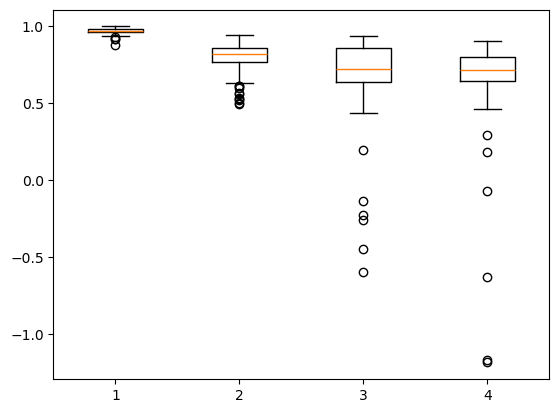

In [6]:
# data = [metrics_cal['KGE'], metrics_tmp['KGE'], metrics_spc['KGE'], metrics_spc_tmp['KGE']]
data = [metrics_cal['KGE'], metrics_tmp['KGE']]

# Multiple box plots on one Axes
fig, ax = plt.subplots()
ax.boxplot(data)

plt.xticks(ticks=[1,2], labels=['calibration', 'validation'])
# plt.ylim(-0.5,1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0.15, 1.05)
plt.title('KGE (2009) for 205 stations', size='16')
plt.show()
# fig.savefig('runs/boxplot_cal_val.png')


# import matplotlib.pyplot as plt

# def color_boxplot(data, color, pos, ax=None):
#     ax = ax or plt.gca()
#     bp = ax.boxplot(data, patch_artist=True,  showmeans=True, positions=pos)
#     for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
#         plt.setp(bp[item], color=color)


# data1 = metrics_cal['KGE']
# data2 = metrics_tmp['KGE']
# data3 = metrics_spc['KGE']
# data4 = metrics_spc_tmp['KGE']

# fig, ax = plt.subplots()
# bp1 = color_boxplot(data1, 'green', [1])
# bp2 = color_boxplot(data2, 'blue', [2])
# bp1 = color_boxplot(data3, 'purple', [3])
# bp2 = color_boxplot(data4, 'red', [4])
# ax.autoscale()
# ax.set(xticks=[1,2,3,4], xticklabels=['train','tmp', 'val_tmp', 'spc'])
# plt.show()

In [7]:
def metric_analysis(df_metric):
    
    d=df_metric['KGE']
    whis=1.5
    
    # finding the 1st quartile
    q1 = np.quantile(d, 0.25)

    # finding the 3rd quartile
    q3 = np.quantile(d, 0.75)
    med = np.median(d)

    # finding the iqr region
    iqr = q3-q1

    # # finding upper and lower whiskers
    # upper_bound = q3+(1.5*iqr)
    # lower_bound = q1-(1.5*iqr)
    

    # get high extreme
    iq = q3 - q1
    hi_val = q3 + whis * iq
    wisk_hi = np.compress(d <= hi_val, d)
    if len(wisk_hi) == 0 or np.max(wisk_hi) < q3:
        wisk_hi = q3
    else:
        wisk_hi = max(wisk_hi)

    # get low extreme
    lo_val = q1 - whis * iq
    wisk_lo = np.compress(d >= lo_val, d)
    if len(wisk_lo) == 0 or np.min(wisk_lo) > q1:
        wisk_lo = q1
    else:
        wisk_lo = min(wisk_lo)

    # Calculate standard deviation
    std_dev = np.std(d)
        
    ##get the outliers
    outliers=df_metric[df_metric['KGE']< wisk_lo][['basin' ,'KGE']]
    
    print('Median: ',med)
    print('Std: ', std_dev)
    # print('upper_bound: ', upper_bound)
    # print('lower_bound: ', lower_bound)
    print('wisk_hi: ',wisk_hi)
    print('wisk_low: ',wisk_lo)

    print('*' *50)
    print("outliers: ")
    return outliers

# Calibration

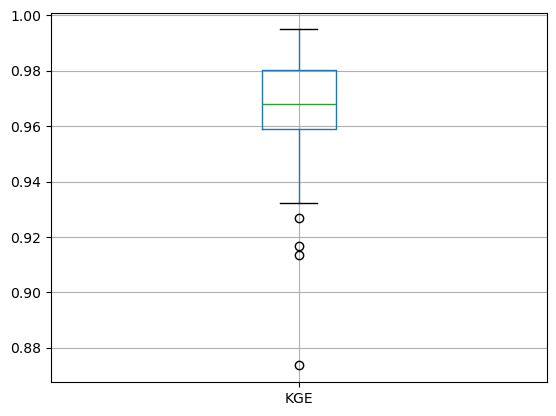

Median:  0.9681749007796746
Std:  0.017870834635348932
wisk_hi:  0.9948929349272865
wisk_low:  0.9323849095418523
**************************************************
outliers: 


,basin,KGE
7,02BD002,0.873620
38,02GA038,0.913440
131,04215500,0.926810
140,04258000,0.916608


In [8]:
metrics_cal.boxplot('KGE')
plt.show()

Train_outliers=metric_analysis(metrics_cal)
Train_outliers

# Temporal Validation

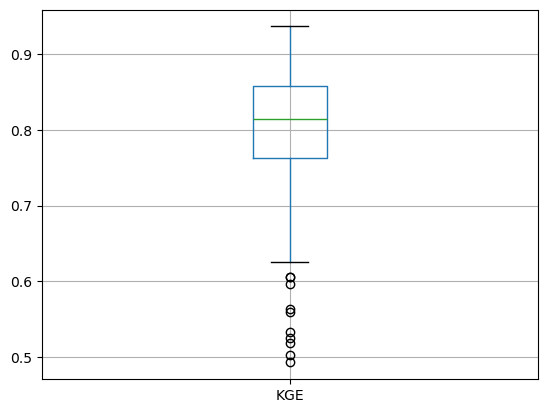

Median:  0.8149785641828107
Std:  0.09307165442860738
wisk_hi:  0.9368525509997595
wisk_low:  0.6259143622684344
**************************************************
outliers: 


,basin,KGE
0,02AB017,0.563167
7,02BD002,0.492451
24,02ED003,0.595977
25,02ED015,0.606142
27,02ED029,0.501974
28,02ED101,0.605730
29,02ED102,0.558839
72,04024430,0.517953
75,04029990,0.532311
106,04126740,0.525313


In [9]:
metrics_tmp.boxplot('KGE')
plt.show()
Tmp_outliers=metric_analysis(metrics_tmp)
Tmp_outliers

# Spatial Validation

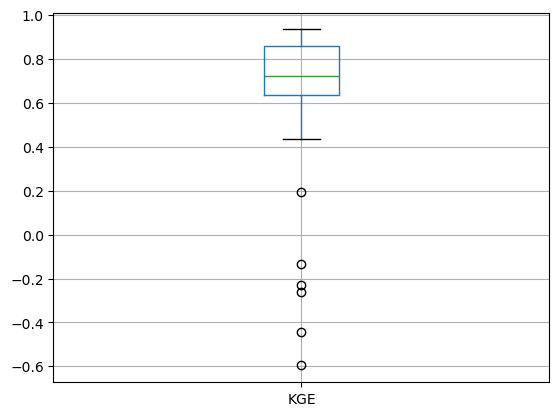

Median:  0.7200766070741738
Std:  0.3092821833255205
wisk_hi:  0.9338082129644018
wisk_low:  0.4331814020465341
**************************************************
outliers: 


,basin,KGE
2,02AD012,-0.228651
8,02BE002,-0.595889
34,02HF002,-0.134558
42,02KF005,-0.261358
49,02LE025,-0.444849
50,02LG005,0.192907


In [10]:
metrics_spc.boxplot('KGE')
plt.show()
valtmp_outliers=metric_analysis(metrics_spc)
valtmp_outliers

# Spatio-Temporal Validation

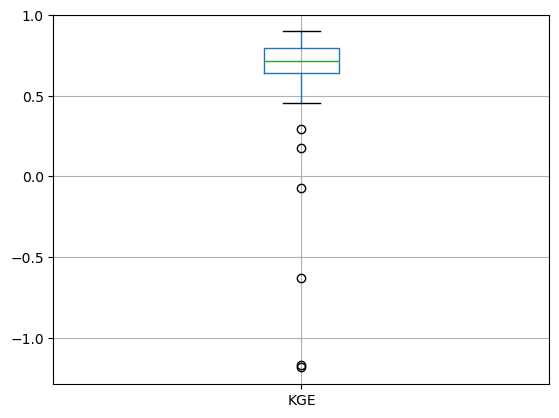

Median:  0.7143262823331911
Std:  0.38003904418358475
wisk_hi:  0.8984446968981782
wisk_low:  0.45681602975040714
**************************************************
outliers: 


,basin,KGE
2,02AD012,-0.072862
8,02BE002,-0.631206
34,02HF002,0.178531
42,02KF005,-1.168260
49,02LE025,-1.183688
50,02LG005,0.292874


In [11]:
metrics_spc_tmp.boxplot('KGE')
plt.show()
spc_outliers=metric_analysis(metrics_spc_tmp)
spc_outliers